# Test download google scholar data

In [1]:
import requests
from bs4 import BeautifulSoup

In [30]:
def getScholarData(keywords,year):
    keywords = '+'.join(keywords.split(' '))
    try:
        url = "https://scholar.google.com/scholar?as_ylo="+str(year)+"&q="+keywords+"&hl=en&as_sdt=0,31"
        headers = {
            "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_11_3) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/100.0.4896.127 Safari/537.36"
        }
        response = requests.get(url, headers=headers)
        soup = BeautifulSoup(response.text, 'html.parser')
 
        scholar_results = []
 
        for el in soup.select(".gs_r"):
            if el.select(".gs_rt") and el.select(".gs_rt a") and el.select(".gs_a") and el.select(".gs_nph+ a") and  el.select("a~ a+ .gs_nph"):
                scholar_results.append({
                    "title": el.select(".gs_rt")[0].text,
                    "title_link": el.select(".gs_rt a")[0]["href"],
                    "id": el.select(".gs_rt a")[0]["id"],
                    "displayed_link": el.select(".gs_a")[0].text,
                    "snippet": el.select(".gs_rs")[0].text.replace("\n", ""),
                    "cited_by_count": el.select(".gs_nph+ a")[0].text,
                    "cited_link": "https://scholar.google.com" + el.select(".gs_nph+ a")[0]["href"],
                    "versions_count": el.select("a~ a+ .gs_nph")[0].text,
                    "versions_link": "https://scholar.google.com" + el.select("a~ a+ .gs_nph")[0]["href"] if el.select("a~ a+ .gs_nph")[0].text else "",
                })
 
        for i in range(len(scholar_results)):
            scholar_results[i] = {key: value for key, value in scholar_results[i].items() if value != "" and value is not None}
 
        return scholar_results
 
    except Exception as e:
        print(e)
 


In [40]:
results = getScholarData('large language model',2020)

In [41]:
results

[{'title': 'The rise and potential of large language model based agents: A survey',
  'title_link': 'https://link.springer.com/article/10.1007/s11432-024-4222-0',
  'id': '1ehcLUIoO5QJ',
  'displayed_link': 'Z Xi, W Chen, X Guo, W He, Y Ding, B Hong…\xa0- Science China\xa0…, 2025 - Springer',
  'snippet': '… general and powerful model to serve as a foundation for building general agents adaptable to diverse scenarios. With their versatile capabilities, large language models (LLMs) pave a …',
  'cited_by_count': 'Cited by 715',
  'cited_link': 'https://scholar.google.com/scholar?cites=10681175205933279445&as_sdt=5,31&sciodt=0,31&hl=en',
  'versions_count': 'All 4 versions',
  'versions_link': 'https://scholar.google.com/scholar?cluster=10681175205933279445&hl=en&as_sdt=0,31&as_ylo=2020'},
 {'title': 'ChatGPT for good? On opportunities and challenges of large language models for education',
  'title_link': 'https://www.sciencedirect.com/science/article/pii/S1041608023000195',
  'id': 'ut

In [42]:
len(results)

10

# Test Langchain

In [43]:
from langchain_openai import ChatOpenAI
gpt4o_chat = ChatOpenAI(model="gpt-4o", temperature=0)

In [44]:
from langchain_core.messages import HumanMessage

# Create a message
msg = HumanMessage(content="Hello world", name="Lance")

# Message list
messages = [msg]

# Invoke the model with a list of messages 
gpt4o_chat.invoke(messages)

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 11, 'total_tokens': 21, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_4691090a87', 'finish_reason': 'stop', 'logprobs': None}, id='run-bb911028-4995-49e9-b3f4-9bd77b62a1bf-0', usage_metadata={'input_tokens': 11, 'output_tokens': 10, 'total_tokens': 21, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [45]:
gpt4o_chat.invoke("how many 'a' are there in abracadebra?")

AIMessage(content='The word "abracadebra" contains 4 instances of the letter \'a\'.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 20, 'total_tokens': 39, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_50cad350e4', 'finish_reason': 'stop', 'logprobs': None}, id='run-059dcafd-3e5f-41d3-946f-e72c8ca69930-0', usage_metadata={'input_tokens': 20, 'output_tokens': 19, 'total_tokens': 39, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [46]:
from langchain_community.tools.tavily_search import TavilySearchResults
tavily_search = TavilySearchResults(max_results=3)
search_docs = tavily_search.invoke("What is LangGraph?")

In [47]:
search_docs

[{'url': 'https://www.langchain.com/langgraph',
  'content': 'LangGraph is a stateful, orchestration framework that brings added control to agent workflows. LangGraph Platform is a service for deploying and scaling LangGraph applications, with an opinionated API for building agent UXs, plus an integrated developer studio.'},
 {'url': 'https://www.datacamp.com/tutorial/langgraph-tutorial',
  'content': 'LangGraph is a library within the LangChain ecosystem that provides a framework for defining, coordinating, and executing multiple LLM agents (or chains) in a structured and efficient manner.'},
 {'url': 'https://medium.com/@cplog/introduction-to-langgraph-a-beginners-guide-14f9be027141',
  'content': 'LangGraph is a powerful tool for building stateful, multi-actor applications with Large Language Models (LLMs). It extends the LangChain…'}]

# Try LangGraph

In [49]:
import os
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "langchain-academy"

from langchain_openai import ChatOpenAI

def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools = [add, multiply, divide]
llm = ChatOpenAI(model="gpt-4o")

# For this ipynb we set parallel tool calling to false as math generally is done sequentially, and this time we have 3 tools that can do math
# the OpenAI model specifically defaults to parallel tool calling for efficiency, see https://python.langchain.com/docs/how_to/tool_calling_parallel/
# play around with it and see how the model behaves with math equations!
llm_with_tools = llm.bind_tools(tools, parallel_tool_calls=False)

In [50]:
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, SystemMessage

# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# Node
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

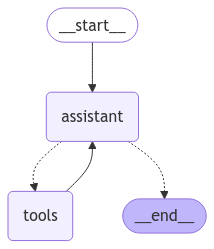

In [51]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine how the control flow moves
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "assistant")
react_graph = builder.compile()

# Show
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [52]:

messages = [HumanMessage(content="Add 3 and 4. Multiply the output by 2. Divide the output by 5")]
messages = react_graph.invoke({"messages": messages})

In [53]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4. Multiply the output by 2. Divide the output by 5
================================== Ai Message ==================================
Tool Calls:
  add (call_0uterwzlXJfFYIUSJNBNHgP5)
 Call ID: call_0uterwzlXJfFYIUSJNBNHgP5
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================
Tool Calls:
  multiply (call_ht9JVvMUzGN6YKOeJG7ZipJJ)
 Call ID: call_ht9JVvMUzGN6YKOeJG7ZipJJ
  Args:
    a: 7
    b: 2
================================= Tool Message =================================
Name: multiply

14
================================== Ai Message ==================================
Tool Calls:
  divide (call_rwRKLjsmIGP46kcw9Y7NuNTW)
 Call ID: call_rwRKLjsmIGP46kcw9Y7NuNTW
  Args:
    a: 14
    b: 5
================================= Tool Message ===============

# Test Neo4j

In [54]:
from neo4j import GraphDatabase, RoutingControl

In [56]:
import os

In [57]:
URI = os.environ.get("NEO4J_URI")
AUTH = ("neo4j", os.environ.get("NEO4J_KEY"))

### Local Neo4j

In [58]:
from neo4j import GraphDatabase

In [61]:
GraphDatabase()

In [64]:
mykey = input("Enter your password: ")

In [65]:
uri = "neo4j://localhost:7687"


connect = GraphDatabase.driver(uri, auth=("neo4j", mykey))

session = connect.session()

In [63]:
session

# My Project -- AI Research Pal

In [ ]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "langchain-academy"

from langchain_openai import ChatOpenAI

def search(keywords: str, year: int):
    """download text based on keywords and oldest year.

    Args:
        keywords: first str
        year: second int
    """
    tavily_search = TavilySearchResults(max_results=10)
    search_docs = tavily_search.invoke("What is "+keywords+"?")
    return search_docs

# This will be a tool
def add_docs(search_docs):
    """add docs to graph database one by one

    Args:
        search_docs: json 
    """
    
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools = [add, multiply, divide]
llm = ChatOpenAI(model="gpt-4o")

# For this ipynb we set parallel tool calling to false as math generally is done sequentially, and this time we have 3 tools that can do math
# the OpenAI model specifically defaults to parallel tool calling for efficiency, see https://python.langchain.com/docs/how_to/tool_calling_parallel/
# play around with it and see how the model behaves with math equations!
llm_with_tools = llm.bind_tools(tools, parallel_tool_calls=False)